In [1]:
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
import json
import faiss
import joblib

import torch

from sklearn.model_selection import train_test_split

from src.models.retrieval_model import retrieval_model_predict

from src.evaluation.metrics import format_cm, evaluate
from sklearn.preprocessing import LabelEncoder

c:\Work\Project\ticket-nlp-classification\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
DATA_PATH = "../data/raw/all_tickets_processed_improved_v3.csv"
df = pd.read_csv(DATA_PATH)
df.head()

X = df["Document"]
y = df["Topic_group"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, shuffle=True, random_state=2)

with open("../artifacts/rac_corpus_similarity-euclidian_index_v01.json", 'r') as f:
    corpus = json.load(f)

similarity_index = faiss.read_index("../artifacts/traindata_similarity_index_v01.index")
euclidian_index = faiss.read_index("../artifacts/traindata_euclidian_index_v01.index")

retrieval_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device=device)

In [3]:
print(f"Y predicted:{retrieval_model_predict(
    text=X_test.to_list()[0],
    retrieval_model=retrieval_model,
    index=similarity_index,
    corpus=corpus,
    keys=["Document", "Topic_group"],
    y_key="Topic_group",
    k=5,
    remove_top=False,
    weight="score"
    )} | actual y: {y_test.to_list()[0]}")

Y predicted:('Hardware', 0.4155360162258148) | actual y: Hardware


In [4]:
y_pred_score_k3 = [ retrieval_model_predict(
    text=_test_data,
    retrieval_model=retrieval_model,
    index=similarity_index,
    corpus=corpus,
    keys=["Document", "Topic_group"],
    y_key="Topic_group",
    k=3,
    remove_top=False,
    weight="score"
    ) for _test_data in X_test.to_list()]

y_pred_score_k5 = [ retrieval_model_predict(
    text=_test_data,
    retrieval_model=retrieval_model,
    index=similarity_index,
    corpus=corpus,
    keys=["Document", "Topic_group"],
    y_key="Topic_group",
    k=5,
    remove_top=False,
    weight="score"
    ) for _test_data in X_test.to_list()]

y_pred_score_k7 = [ retrieval_model_predict(
    text=_test_data,
    retrieval_model=retrieval_model,
    index=similarity_index,
    corpus=corpus,
    keys=["Document", "Topic_group"],
    y_key="Topic_group",
    k=7,
    remove_top=False,
    weight="score"
    ) for _test_data in X_test.to_list()]

y_pred_score_k10 = [ retrieval_model_predict(
    text=_test_data,
    retrieval_model=retrieval_model,
    index=similarity_index,
    corpus=corpus,
    keys=["Document", "Topic_group"],
    y_key="Topic_group",
    k=10,
    remove_top=False,
    weight="score"
    ) for _test_data in X_test.to_list()]

In [11]:
y_pred_score_k20 = [ retrieval_model_predict(
    text=_test_data,
    retrieval_model=retrieval_model,
    index=similarity_index,
    corpus=corpus,
    keys=["Document", "Topic_group"],
    y_key="Topic_group",
    k=20,
    remove_top=False,
    weight="score"
    ) for _test_data in X_test.to_list()]

In [7]:
# cm k = 3

format_cm(
    evaluate(y_test.to_list(), [_y[0] for _y in y_pred_score_k3]), class_names=y.unique().tolist(), normalize=True
)

                       precision    recall  f1-score   support

               Access     0.8672    0.8618    0.8645      1425
Administrative rights     0.7981    0.7074    0.7500       352
           HR Support     0.7913    0.8456    0.8175      2183
             Hardware     0.8106    0.8062    0.8084      2724
     Internal Project     0.8000    0.7453    0.7717       424
        Miscellaneous     0.7851    0.7528    0.7686      1412
             Purchase     0.8996    0.8905    0.8950       493
              Storage     0.8396    0.8486    0.8441       555

             accuracy                         0.8161      9568
            macro avg     0.8239    0.8073    0.8150      9568
         weighted avg     0.8162    0.8161    0.8157      9568



,Pred: Hardware,Pred: Access,Pred: Miscellaneous,Pred: HR Support,Pred: Purchase,Pred: Administrative rights,Pred: Storage,Pred: Internal Project
True: Hardware,0.861754,0.002807,0.048421,0.046316,0.007018,0.021754,0.002105,0.009825
True: Access,0.019886,0.707386,0.039773,0.198864,0.002841,0.019886,0.011364,0.000000
True: Miscellaneous,0.017407,0.002749,0.845625,0.068713,0.008246,0.047641,0.000458,0.009162
True: HR Support,0.032305,0.012849,0.075624,0.806167,0.008076,0.040015,0.012849,0.012115
True: Purchase,0.025943,0.004717,0.113208,0.044811,0.745283,0.058962,0.002358,0.004717
True: Administrative rights,0.021955,0.005666,0.080028,0.105524,0.016289,0.752833,0.002833,0.014873
True: Storage,0.012170,0.006085,0.028398,0.040568,0.010142,0.012170,0.890467,0.000000
True: Internal Project,0.012613,0.009009,0.041441,0.070270,0.000000,0.016216,0.001802,0.848649


In [8]:
# cm k = 5

format_cm(
    evaluate(y_test.to_list(), [_y[0] for _y in y_pred_score_k5]), class_names=y.unique().tolist(), normalize=True
)

                       precision    recall  f1-score   support

               Access     0.8882    0.8639    0.8758      1425
Administrative rights     0.8407    0.7045    0.7666       352
           HR Support     0.7970    0.8667    0.8304      2183
             Hardware     0.8213    0.8234    0.8224      2724
     Internal Project     0.8182    0.7429    0.7787       424
        Miscellaneous     0.7923    0.7592    0.7754      1412
             Purchase     0.8998    0.9108    0.9052       493
              Storage     0.8716    0.8559    0.8636       555

             accuracy                         0.8283      9568
            macro avg     0.8411    0.8159    0.8273      9568
         weighted avg     0.8290    0.8283    0.8279      9568



,Pred: Hardware,Pred: Access,Pred: Miscellaneous,Pred: HR Support,Pred: Purchase,Pred: Administrative rights,Pred: Storage,Pred: Internal Project
True: Hardware,0.863860,0.002105,0.051228,0.046316,0.005614,0.023158,0.001404,0.006316
True: Access,0.019886,0.704545,0.036932,0.190341,0.000000,0.028409,0.017045,0.002841
True: Miscellaneous,0.014201,0.002290,0.866697,0.059551,0.008246,0.042144,0.000458,0.006413
True: HR Support,0.025330,0.009545,0.073789,0.823421,0.006608,0.041116,0.012482,0.007709
True: Purchase,0.021226,0.004717,0.103774,0.061321,0.742925,0.054245,0.004717,0.007075
True: Administrative rights,0.020538,0.001416,0.084986,0.099150,0.015581,0.759207,0.003541,0.015581
True: Storage,0.008114,0.008114,0.022312,0.042596,0.008114,0.000000,0.910751,0.000000
True: Internal Project,0.010811,0.009009,0.036036,0.068468,0.000000,0.019820,0.000000,0.855856


In [9]:
# cm k = 7

format_cm(
    evaluate(y_test.to_list(), [_y[0] for _y in y_pred_score_k7]), class_names=y.unique().tolist(), normalize=True
)

                       precision    recall  f1-score   support

               Access     0.8922    0.8596    0.8756      1425
Administrative rights     0.8497    0.6903    0.7618       352
           HR Support     0.8050    0.8699    0.8362      2183
             Hardware     0.8185    0.8363    0.8273      2724
     Internal Project     0.8355    0.7429    0.7865       424
        Miscellaneous     0.8000    0.7677    0.7835      1412
             Purchase     0.8851    0.9067    0.8958       493
              Storage     0.8925    0.8523    0.8719       555

             accuracy                         0.8324      9568
            macro avg     0.8473    0.8157    0.8298      9568
         weighted avg     0.8333    0.8324    0.8320      9568



,Pred: Hardware,Pred: Access,Pred: Miscellaneous,Pred: HR Support,Pred: Purchase,Pred: Administrative rights,Pred: Storage,Pred: Internal Project
True: Hardware,0.859649,0.000702,0.050526,0.051228,0.006316,0.022456,0.002807,0.006316
True: Access,0.019886,0.690341,0.039773,0.198864,0.002841,0.022727,0.022727,0.002841
True: Miscellaneous,0.012368,0.001832,0.869904,0.062300,0.006871,0.041686,0.000458,0.004581
True: HR Support,0.024963,0.008443,0.067915,0.836270,0.005507,0.037812,0.012849,0.006241
True: Purchase,0.021226,0.007075,0.089623,0.068396,0.742925,0.058962,0.007075,0.004717
True: Administrative rights,0.018414,0.002833,0.088527,0.092068,0.012748,0.767705,0.004958,0.012748
True: Storage,0.008114,0.004057,0.020284,0.050710,0.008114,0.002028,0.906694,0.000000
True: Internal Project,0.012613,0.010811,0.028829,0.075676,0.000000,0.019820,0.000000,0.852252


In [10]:
# cm k = 10

format_cm(
    evaluate(y_test.to_list(), [_y[0] for _y in y_pred_score_k10]), class_names=y.unique().tolist(), normalize=True
)

                       precision    recall  f1-score   support

               Access     0.9020    0.8589    0.8799      1425
Administrative rights     0.8521    0.6875    0.7610       352
           HR Support     0.7999    0.8736    0.8351      2183
             Hardware     0.8196    0.8370    0.8282      2724
     Internal Project     0.8429    0.7594    0.7990       424
        Miscellaneous     0.8092    0.7720    0.7901      1412
             Purchase     0.8691    0.9026    0.8856       493
              Storage     0.8981    0.8414    0.8688       555

             accuracy                         0.8337      9568
            macro avg     0.8491    0.8166    0.8310      9568
         weighted avg     0.8352    0.8337    0.8334      9568



,Pred: Hardware,Pred: Access,Pred: Miscellaneous,Pred: HR Support,Pred: Purchase,Pred: Administrative rights,Pred: Storage,Pred: Internal Project
True: Hardware,0.858947,0.000702,0.051228,0.050526,0.006316,0.022456,0.004211,0.005614
True: Access,0.022727,0.687500,0.039773,0.190341,0.005682,0.022727,0.028409,0.002841
True: Miscellaneous,0.008246,0.001832,0.873568,0.064590,0.006871,0.038479,0.001374,0.005039
True: HR Support,0.023128,0.010279,0.069016,0.837004,0.004772,0.037078,0.013583,0.005140
True: Purchase,0.018868,0.007075,0.108491,0.047170,0.759434,0.044811,0.007075,0.007075
True: Administrative rights,0.016997,0.001416,0.086402,0.094901,0.011331,0.771955,0.005666,0.011331
True: Storage,0.010142,0.000000,0.024341,0.048682,0.008114,0.006085,0.902637,0.000000
True: Internal Project,0.012613,0.007207,0.039640,0.079279,0.001802,0.018018,0.000000,0.841441


In [13]:
# cm k = 20

format_cm(
    evaluate(y_test.to_list(), [_y[0] for _y in y_pred_score_k20]), class_names=y.unique().tolist(), normalize=True
)

                       precision    recall  f1-score   support

               Access     0.9156    0.8604    0.8871      1425
Administrative rights     0.8826    0.6619    0.7565       352
           HR Support     0.7976    0.8704    0.8324      2183
             Hardware     0.8127    0.8410    0.8266      2724
     Internal Project     0.8342    0.7594    0.7951       424
        Miscellaneous     0.8021    0.7635    0.7823      1412
             Purchase     0.8713    0.9067    0.8887       493
              Storage     0.8964    0.8414    0.8680       555

             accuracy                         0.8324      9568
            macro avg     0.8516    0.8131    0.8296      9568
         weighted avg     0.8344    0.8324    0.8320      9568



,Pred: Hardware,Pred: Access,Pred: Miscellaneous,Pred: HR Support,Pred: Purchase,Pred: Administrative rights,Pred: Storage,Pred: Internal Project
True: Hardware,0.860351,0.000000,0.050526,0.052632,0.007719,0.020351,0.003509,0.004912
True: Access,0.014205,0.661932,0.042614,0.221591,0.002841,0.025568,0.028409,0.002841
True: Miscellaneous,0.009620,0.000458,0.870362,0.063674,0.005039,0.041686,0.001832,0.007329
True: HR Support,0.021292,0.006975,0.070485,0.841043,0.006608,0.035977,0.012482,0.005140
True: Purchase,0.011792,0.009434,0.110849,0.051887,0.759434,0.047170,0.004717,0.004717
True: Administrative rights,0.012040,0.001416,0.087819,0.104108,0.014164,0.763456,0.007082,0.009915
True: Storage,0.006085,0.000000,0.024341,0.048682,0.006085,0.008114,0.906694,0.000000
True: Internal Project,0.007207,0.009009,0.036036,0.077477,0.000000,0.027027,0.001802,0.841441


(array([   0.,    0.,   54.,  391.,  673.,  903.,  798.,  800.,  821.,
         735.,    0., 4393.]),
 array([0.  , 0.1 , 0.2 , 0.3 , 0.4 , 0.5 , 0.6 , 0.7 , 0.8 , 0.9 , 0.95,
        0.99, 1.  ]),
 <BarContainer object of 12 artists>)

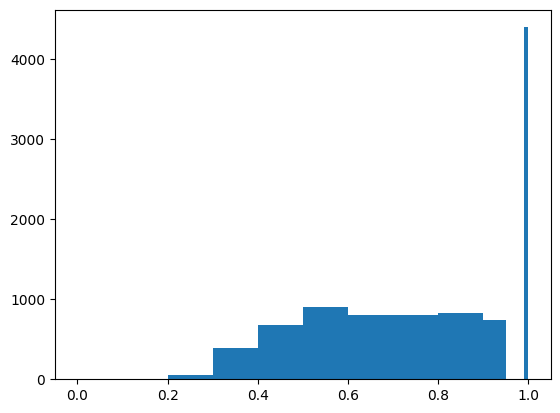

In [15]:
import matplotlib.pyplot as plt
# score distribution for k = 10

plt.hist([_y[1] for _y in y_pred_score_k10], bins = [0.0, 0.1,0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99, 1.0])

In [39]:
# let us find the best k
from sklearn.metrics import classification_report
get_score = lambda data: data['macro avg']['f1-score']
best_k = 10
cr_history = [classification_report(y_test.to_list(), [_y[0] for _y in y_pred_score_k10], digits=4, output_dict= True)]
y_pred_score_history = [y_pred_score_k10]
best_score = get_score(cr_history[0])
k_vals = list(range(10, 20))

for k in range(11, 20):
    y_pred_score_k = [ retrieval_model_predict(
    text=_test_data,
    retrieval_model=retrieval_model,
    index=similarity_index,
    corpus=corpus,
    keys=["Document", "Topic_group"],
    y_key="Topic_group",
    k=k,
    remove_top=False,
    weight="score"
    ) for _test_data in X_test.to_list()]
    
    _cr = classification_report(y_test.to_list(), [_y[0] for _y in y_pred_score_k], digits=4, output_dict= True)
    cr_history.append(_cr)
    y_pred_score_history.append(y_pred_score_k)
    
    _score = get_score(_cr)
    if _score > best_score:
        best_score = _score
        best_k = k

In [42]:
print(best_k)
print(cr_history[k_vals.index(best_k)])
print(get_score(cr_history[k_vals.index(best_k)]))

18
{'Access': {'precision': 0.9175946547884187, 'recall': 0.8673684210526316, 'f1-score': 0.8917748917748918, 'support': 1425.0}, 'Administrative rights': {'precision': 0.8872180451127819, 'recall': 0.6704545454545454, 'f1-score': 0.7637540453074434, 'support': 352.0}, 'HR Support': {'precision': 0.8036317567567568, 'recall': 0.8717361429225836, 'f1-score': 0.8362997143484948, 'support': 2183.0}, 'Hardware': {'precision': 0.8183108587650816, 'recall': 0.8465491923641704, 'f1-score': 0.8321905449296283, 'support': 2724.0}, 'Internal Project': {'precision': 0.8372093023255814, 'recall': 0.7641509433962265, 'f1-score': 0.7990135635018496, 'support': 424.0}, 'Miscellaneous': {'precision': 0.8078927773641102, 'recall': 0.7684135977337111, 'f1-score': 0.7876588021778584, 'support': 1412.0}, 'Purchase': {'precision': 0.8662790697674418, 'recall': 0.9066937119675457, 'f1-score': 0.8860257680872151, 'support': 493.0}, 'Storage': {'precision': 0.904397705544933, 'recall': 0.8522522522522522, 'f1

In [43]:
format_cm(
    evaluate(y_test.to_list(), [_y[0] for _y in y_pred_score_history[k_vals.index(best_k)]]), class_names=y.unique().tolist(), normalize=True
)

                       precision    recall  f1-score   support

               Access     0.9176    0.8674    0.8918      1425
Administrative rights     0.8872    0.6705    0.7638       352
           HR Support     0.8036    0.8717    0.8363      2183
             Hardware     0.8183    0.8465    0.8322      2724
     Internal Project     0.8372    0.7642    0.7990       424
        Miscellaneous     0.8079    0.7684    0.7877      1412
             Purchase     0.8663    0.9067    0.8860       493
              Storage     0.9044    0.8523    0.8776       555

             accuracy                         0.8372      9568
            macro avg     0.8553    0.8185    0.8343      9568
         weighted avg     0.8390    0.8372    0.8368      9568



,Pred: Hardware,Pred: Access,Pred: Miscellaneous,Pred: HR Support,Pred: Purchase,Pred: Administrative rights,Pred: Storage,Pred: Internal Project
True: Hardware,0.867368,0.000000,0.050526,0.044912,0.007719,0.021053,0.004912,0.003509
True: Access,0.014205,0.670455,0.039773,0.213068,0.002841,0.025568,0.031250,0.002841
True: Miscellaneous,0.007787,0.000458,0.871736,0.065964,0.004581,0.040770,0.001832,0.006871
True: HR Support,0.020558,0.007342,0.066079,0.846549,0.006975,0.035242,0.012849,0.004405
True: Purchase,0.011792,0.007075,0.108491,0.056604,0.764151,0.040094,0.004717,0.007075
True: Administrative rights,0.013456,0.001416,0.087110,0.099150,0.014164,0.768414,0.006374,0.009915
True: Storage,0.006085,0.000000,0.024341,0.050710,0.004057,0.008114,0.906694,0.000000
True: Internal Project,0.010811,0.007207,0.032432,0.072072,0.000000,0.023423,0.001802,0.852252


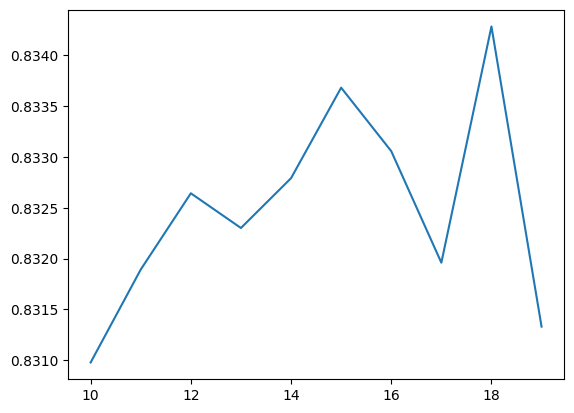

In [48]:
plt.plot(k_vals, [get_score(_c) for _c in cr_history])

In [51]:
val = 0
for k, _c in zip(k_vals, cr_history):
    val += k * get_score(_c)

val / len(k_vals)

12.072105501203156